#    **DATA SCIENCE PROJECT**

##  **Titanic Survival Prediction using Machine Learning**

## **PROBLEM DEFINITION**

The goal of this project is to predict whether a passenger survived or not using machine learning techniques based on features such as age, gender, class, and fare.

## **DATASET DESCRIPTION**

Source: https://www.kaggle.com/c/titanic/data

The dataset used in this project is the Titanic dataset from Kaggle. It contains information about passengers such as age, gender, passenger class, fare, and survival status.



**IMPORT LIBRARIES**




In [2]:
import pandas as pd
 # Import pandas library for data handling

import seaborn as sns
# Used for data visualization (advanced graphs like heatmaps, countplots)

import matplotlib.pyplot as plt
# Used for basic plotting and graphs (histogram, scatter, etc.)

from sklearn.model_selection import train_test_split
 # Used to split dataset into training and testing sets

from sklearn.preprocessing import StandardScaler
 # Used to scale numerical features so they have similar ranges

from sklearn.linear_model import LogisticRegression
 # Machine learning model used for binary classification

from sklearn.tree import DecisionTreeClassifier
# Machine learning model that uses tree structure for

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Used to evaluate model performance (accuracy, error analysis, detailed report)

**LOAD DATASET**

In [3]:
df = pd.read_csv('train.csv') # Load the dataset (Titanic training data) from CSV (comma separated values) file into a pandas DataFrame (df) for analysis


In [4]:
df.head()                        ## Display first 5 rows of the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**DATA UNDERSTANDING**


In [5]:
# Check basic information about dataset eg# rows ,column ,missing values etc
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:

# Check summary statistics (mean, min, max, std, etc.) for numerical columns in the dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
 df.isnull().sum()
# Check total number of missing (null) values in each column of the dataset

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Count values in Embarked column
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


##  **DATA PROCESSING**

In this step, missing values were handled, irrelevant columns were removed, and categorical variables were converted into numerical format to prepare the dataset for modeling.

In [7]:
# Remove unnecessary columns from the dataset to simplify the model and improve performance
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [8]:
# Fill missing values in Age column using mean (average age)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing values in Embarked column using mode (most frequent category)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
# Convert categorical columns (Sex, Embarked) into numerical format using one-hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [10]:
df.head()  #Irrelevant columns such as Name, Ticket, Cabin, and PassengerId were removed
          #before encoding to avoid unnecessary complexity.

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [11]:
# Display a message to indicate that we are checking missing values after preprocessing
print("Missing values after cleaning:")

# Show the number of missing values in each column to confirm that data is clean
print(df.isnull().sum())

Missing values after cleaning:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64


##  **OUTLIER DETECTION AND REMOVAL**

Outliers in the Fare column were detected and removed using the IQR method to improve model performance.

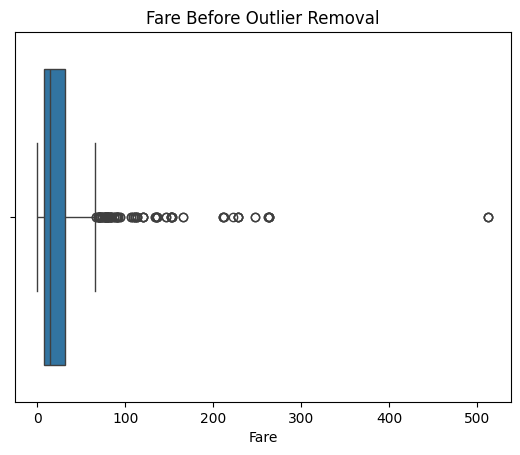

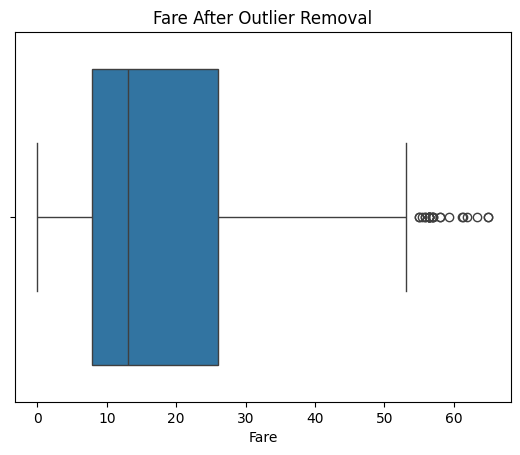

In [12]:
sns.boxplot(x=df['Fare'])
# Create a boxplot to visualize the distribution of Fare and detect outliers

plt.title("Fare Before Outlier Removal")
# Add title to the graph

plt.show()
# Display the plot

Q1 = df['Fare'].quantile(0.25)
# Calculate the first quartile (25th percentile)

Q3 = df['Fare'].quantile(0.75)
# Calculate the third quartile (75th percentile)

IQR = Q3 - Q1
# Calculate Interquartile Range (IQR)

df = df[(df['Fare'] >= Q1 - 1.5 * IQR) & (df['Fare'] <= Q3 + 1.5 * IQR)]
# Remove outliers using IQR method (keep only values within acceptable range)

sns.boxplot(x=df['Fare'])
# Plot boxplot again to confirm outliers are removed

plt.title("Fare After Outlier Removal")
# Add title after cleaning

plt.show()
# Display updated plot


The first graph shows that there are many outliers in the Fare column (very high values).  
The second graph shows that after removing these outliers, the data becomes more clean and balanced.

## **EXPLORATORY DATA ANALYSIS (EDA)**

EDA was performed to understand patterns and relationships in the data using statistical summaries and visualizations such as histograms, boxplots, and heatmaps.




In [13]:
df.shape  # Check dataset shape (rows, columns)

(775, 9)

In [14]:
df.columns # Check column names

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [15]:
df.dtypes  #check data type

,0
Survived,int64
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,bool
Embarked_Q,bool
Embarked_S,bool


In [16]:
# Count the number of passengers who survived (1) and did not survive (0)
df['Survived'].value_counts()

,count
Survived,
0,512
1,263


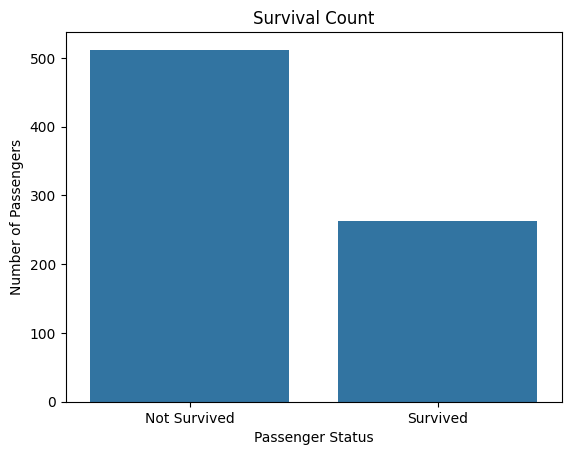

In [17]:
# Create countplot for survival
sns.countplot(x='Survived', data=df)
# Plot number of passengers who survived (1) and not survived (0)

plt.title("Survival Count")
# Add title to the graph

# Replace numeric labels (0,1) with meaningful text
plt.xticks([0, 1], ['Not Survived', 'Survived'])

plt.xlabel("Passenger Status")
# Set clear label for x-axis

plt.ylabel("Number of Passengers")
# Set clear label for y-axis

plt.show()
# Display the graph

The graph shows that most passengers did not survive, while fewer passengers survived.

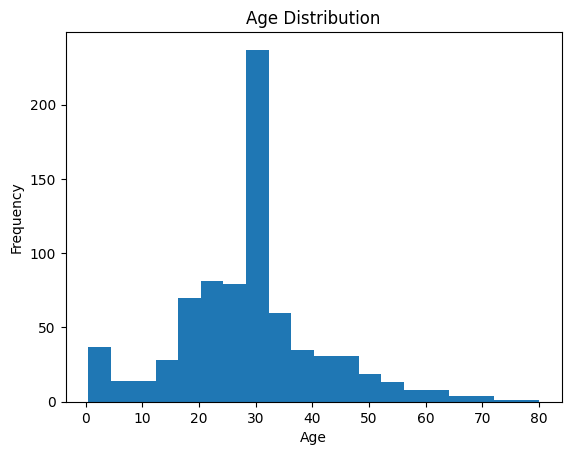

In [18]:
# Age Distribution
plt.hist(df['Age'], bins=20)
# Create histogram to show distribution of Age values

plt.title("Age Distribution")
# Add title to the graph

plt.xlabel("Age")
# Label x-axis (Age values)

plt.ylabel("Frequency")
# Label y-axis (number of passengers)

plt.show()
# Display the graph

The histogram shows the distribution of passenger ages. Most passengers are in the age range of 20 to 40, while very young and very old passengers are fewer.

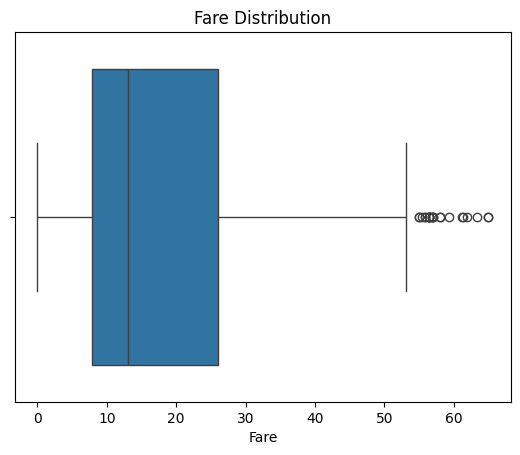

In [19]:
# Fare Distribution
sns.boxplot(x=df['Fare'])
# Create a boxplot to visualize distribution of Fare and identify outliers

plt.title("Fare Distribution")
# Add title to the graph

plt.show()
# Display the plot

Most passengers paid low fares, while a few paid very high fares (outliers).

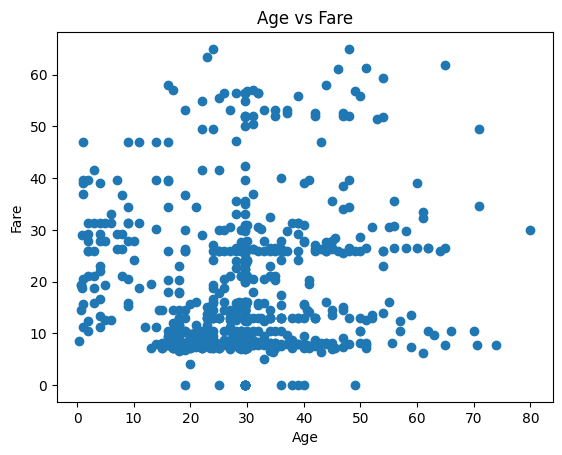

In [20]:
# Scatter Plot (Age vs Fare)
plt.scatter(df['Age'], df['Fare'])
# Create scatter plot to show relationship between Age and Fare

plt.title("Age vs Fare")
# Add title to the graph

plt.xlabel("Age")
# Label x-axis (Age values)

plt.ylabel("Fare")
# Label y-axis (Fare values)

plt.show()
# Display the plot

The scatter plot shows the relationship between Age and Fare. Most passengers paid low fares regardless of their age. There is no clear strong relationship between age and fare, as the points are scattered randomly.

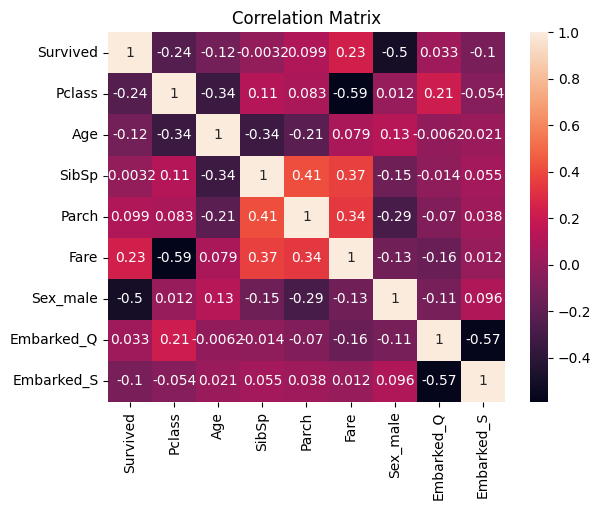

In [21]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
# Create heatmap to show correlation between numerical features

plt.title("Correlation Matrix")
# Add title to the graph

plt.show()
# Display the heatmap

The heatmap shows the relationship between features. Sex_male has a negative effect on survival, while Fare has a positive effect. Other features have weak relationships.

##   **FEATURE ENGINEERING**

A new feature called FamilySize was created by combining SibSp and Parch to better represent passenger family relationships.

In [22]:
df['FamilySize'] = df['SibSp'] + df['Parch']
# Create a new feature 'FamilySize' by adding number of siblings/spouses and parents/children

In [23]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,0,3,22.000000,1,0,7.2500,True,False,True,1
2,1,3,26.000000,0,0,7.9250,False,False,True,0
3,1,1,35.000000,1,0,53.1000,False,False,True,1
4,0,3,35.000000,0,0,8.0500,True,False,True,0
5,0,3,29.699118,0,0,8.4583,True,True,False,0


**FEATURE SELECTION**

In [25]:
correlation = df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
# Calculate correlation of all numerical features with 'Survived' and sort them in descending order

correlation
# Display correlation values


,Survived
Survived,1.000000
Fare,0.234422
Parch,0.098575
FamilySize,0.052674
Embarked_Q,0.032707
SibSp,-0.003156
Embarked_S,-0.102337
Age,-0.121283
Pclass,-0.238532
Sex_male,-0.499888


**FEATURE SCALING**

In [27]:
scaler = StandardScaler()
# Create scaler to normalize numerical data

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])
# Scale Age and Fare so both features are on the same range

In [ ]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,0,3,22.000000,1,0,7.2500,True,False,True,1
2,1,3,26.000000,0,0,7.9250,False,False,True,0
3,1,1,35.000000,1,0,53.1000,False,False,True,1
4,0,3,35.000000,0,0,8.0500,True,False,True,0
5,0,3,29.699118,0,0,8.4583,True,True,False,0


**TRAIN_TEST SPLIT**

In [28]:
from sklearn.model_selection import train_test_split
# Import function to split dataset into training and testing sets


# Separate features and target
X = df.drop('Survived', axis=1)
# X contains all input features (independent variables)

y = df['Survived']
# y contains target variable (what we want to predict)


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Split data into training (80%) and testing (20%) sets


**MODEL BUILDING**

Two machine learning models, Logistic Regression and Decision Tree, were implemented to predict passenger survival.

Logistic Regression Accuracy: 0.7483870967741936


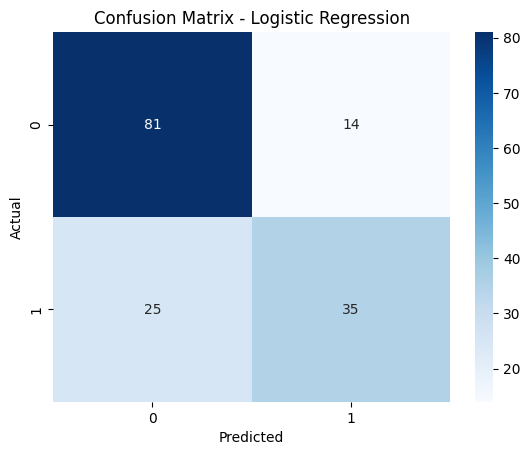

Confusion Matrix:
[[81 14]
 [25 35]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81        95
           1       0.71      0.58      0.64        60

    accuracy                           0.75       155
   macro avg       0.74      0.72      0.72       155
weighted avg       0.74      0.75      0.74       155



In [29]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train model on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Import evaluation functions
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

# Confusion Matrix (Logistic Regression - Graph)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


The confusion matrix shows that the model correctly predicted 81 passengers as not survived and 35 as survived. However, it incorrectly predicted 14 passengers as survived and 25 as not survived.

Decision Tree Accuracy: 0.7741935483870968


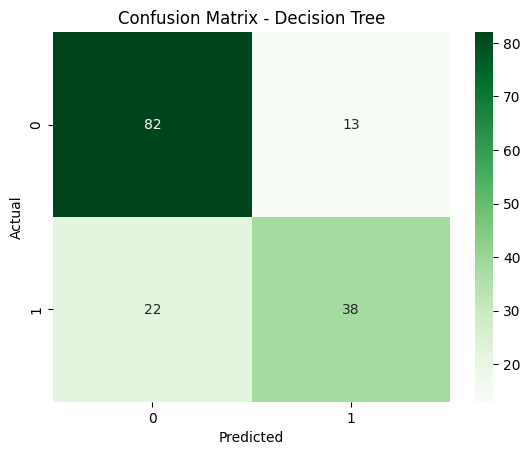

Decision Tree Confusion Matrix:
[[82 13]
 [22 38]]
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        95
           1       0.75      0.63      0.68        60

    accuracy                           0.77       155
   macro avg       0.77      0.75      0.75       155
weighted avg       0.77      0.77      0.77       155



In [30]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create model

model2 = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train model
model2.fit(X_train, y_train)

# Predict using Decision Tree
y_pred2 = model2.predict(X_test)

# Check accuracy
accuracy2 = accuracy_score(y_test, y_pred2)

print("Decision Tree Accuracy:", accuracy2)

# Confusion Matrix (Decision Tree - Graph)
cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred2))

# Classification Report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred2))


The confusion matrix shows that the Decision Tree model correctly predicted 82 passengers as not survived and 38 as survived. It made fewer errors compared to Logistic Regression, with 13 incorrect predictions for not survived and 22 for survived cases.

## **MODEL EVALUTION**

The models were evaluated using accuracy, confusion matrix, and classification report. The performance of both models was compared.

In [31]:
if accuracy > accuracy2:
    print("Best Model: Logistic Regression")
    # If Logistic Regression accuracy is higher, select it as best model
else:
    print("Best Model: Decision Tree")
    # Otherwise, Decision Tree is the better model

Best Model: Decision Tree


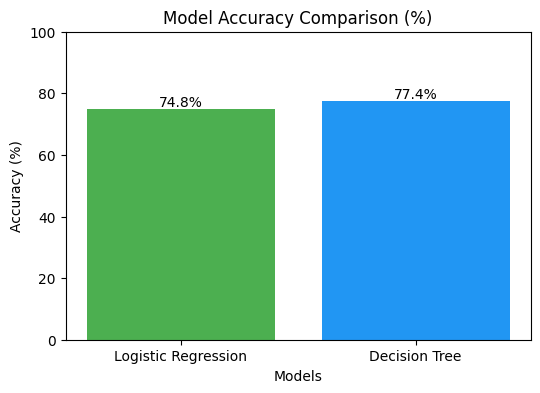

In [33]:
# Model Accuracy Comparison graph

models = ['Logistic Regression', 'Decision Tree']
# List of model names

accuracies = [accuracy * 100, accuracy2 * 100]
# Convert accuracy values into percentage


plt.figure(figsize=(6,4))
# Set size of the graph

bars = plt.bar(models, accuracies, color=['#4CAF50', '#2196F3'])
# Create bar chart for model comparison


plt.title("Model Accuracy Comparison (%)")
# Add title

plt.xlabel("Models")
# Label x-axis

plt.ylabel("Accuracy (%)")
# Label y-axis


# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             f'{yval:.1f}%', ha='center', fontsize=10)
# Display accuracy values on each bar


plt.ylim(0, 100)
# Set y-axis range from 0 to 100

plt.show()
# Display the graph

The graph shows that the Decision Tree model achieved higher accuracy (77.4%) compared to Logistic Regression (74.8%), making it the better performing model.

# **SURVIVAL PREDICTION**
The following table shows the comparison between actual and predicted survival outcomes for selected passengers.

In [34]:
# Final Prediction Table

results = pd.DataFrame({
    'Actual Outcome': y_test.values,
    # Store actual values from test data

    'Predicted Outcome': y_pred
    # Store model predictions
})

# Convert to readable labels
results['Actual Outcome'] = results['Actual Outcome'].replace({0: 'Not Survived', 1: 'Survived'})
# Replace 0/1 with readable labels in actual values

results['Predicted Outcome'] = results['Predicted Outcome'].replace({0: 'Not Survived', 1: 'Survived'})
# Replace 0/1 with readable labels in predicted values

results.head(10)
# Display first 10 rows of results


,Actual Outcome,Predicted Outcome
0,Not Survived,Not Survived
1,Survived,Not Survived
2,Survived,Survived
3,Not Survived,Not Survived
4,Not Survived,Not Survived
5,Not Survived,Not Survived
6,Not Survived,Not Survived
7,Survived,Survived
8,Survived,Survived
9,Survived,Not Survived


## **RESULT SUMMARY**

The Decision Tree model achieved higher accuracy compared to Logistic Regression and was selected as the best-performing model.

## **CONCLUSION**

In this project, the Titanic dataset was analyzed to predict passenger survival using data science techniques. Data preprocessing was performed to handle missing values, remove irrelevant features, and prepare the dataset for analysis. Exploratory Data Analysis (EDA) helped in understanding patterns and relationships within the data.

Feature engineering was applied by creating a new feature (FamilySize) to improve the dataset. Two machine learning models, Logistic Regression and Decision Tree, were implemented and evaluated using accuracy, confusion matrix, and classification report.

The results showed that the Decision Tree model performed better than Logistic Regression in terms of accuracy. This indicates that the Decision Tree was more effective for this dataset.

One limitation of this project is that the dataset is relatively small and may not capture all real-world variations. Additionally, some important features might be missing, which can affect model performance